# Discovery: Statistical Tests and Visualization

This notebook performs three independence tests:
1. **Marginal Independence**: X1 ⊥ X3 (permutation test with CODEC)
2. **Residual Independence**: res_X2 ⊥ (X1, X3) where res_X2 = X2 - E[X2|X1,X3] (permutation test with CODEC)
3. **Conditional Independence**: X1 ⊥ X3 | X2 (MCODEC + diffusion models)

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import os

# Add parent directory to path
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from utils.mcodec import mcodec, codec

# Set up plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete!")

Setup complete!


## Load Data

In [2]:
# Load original data
data = pd.read_csv('./data/discovery.csv')
X1 = data['X1'].values.reshape(-1, 1)
X2 = data['X2'].values.reshape(-1, 1)
X3 = data['X3'].values.reshape(-1, 1)

print(f"Data shape: {data.shape}")
print(f"\nSummary statistics:")
print(data.describe())

Data shape: (500, 3)

Summary statistics:
               X1          X2          X3
count  500.000000  500.000000  500.000000
mean     0.006838    1.652511    0.223372
std      0.981253   10.220865    3.215480
min     -3.241267  -86.229972   -4.802951
25%     -0.700307   -0.304723   -1.379597
50%      0.012797    0.831871   -0.049507
75%      0.636783    2.760408    1.091438
max      3.852731  105.909771   45.895691


## Task 1: Marginal Independence Test (X1 ⊥ X3)

Test if X1 and X3 are marginally independent using permutation test with MCODEC score.

In [3]:
# Compute observed CODEC score (marginal independence)
print("Computing observed CODEC(X1, X3)...")
codec_observed_task1 = codec(X1, X3)
print(f"Observed CODEC score: {codec_observed_task1:.6f}")

# Permutation test
n_permutations = 500
print(f"\nPerforming {n_permutations} permutations...")

codec_null_task1 = []
np.random.seed(42)

for i in range(n_permutations):
    if (i + 1) % 100 == 0:
        print(f"  Permutation {i+1}/{n_permutations}...")
    
    # Permute X3
    X3_perm = X3[np.random.permutation(len(X3))]
    
    # Compute CODEC with permuted data
    codec_perm = codec(X1, X3_perm)
    codec_null_task1.append(codec_perm)

codec_null_task1 = np.array(codec_null_task1)

# Compute p-value
num_larger = np.sum(codec_null_task1 >= codec_observed_task1)
p_value_task1 = (1 + num_larger) / (n_permutations + 1)

print(f"\nResults:")
print(f"  Observed CODEC:      {codec_observed_task1:.6f}")
print(f"  Null mean:           {codec_null_task1.mean():.6f}")
print(f"  Null std:            {codec_null_task1.std():.6f}")
print(f"  # larger or equal:   {num_larger}")
print(f"  P-value:             {p_value_task1:.6f}")
print(f"\nDecision (α=0.05): {'REJECT H0' if p_value_task1 <= 0.05 else 'FAIL TO REJECT H0'}")
print(f"  → X1 and X3 are {'NOT independent' if p_value_task1 <= 0.05 else 'marginally independent'}")

Computing observed CODEC(X1, X3)...
Observed CODEC score: 0.251461

Performing 500 permutations...
  Permutation 100/500...
  Permutation 200/500...
  Permutation 300/500...
  Permutation 400/500...
  Permutation 500/500...

Results:
  Observed CODEC:      0.251461
  Null mean:           -0.000236
  Null std:            0.047012
  # larger or equal:   0
  P-value:             0.001996

Decision (α=0.05): REJECT H0
  → X1 and X3 are NOT independent


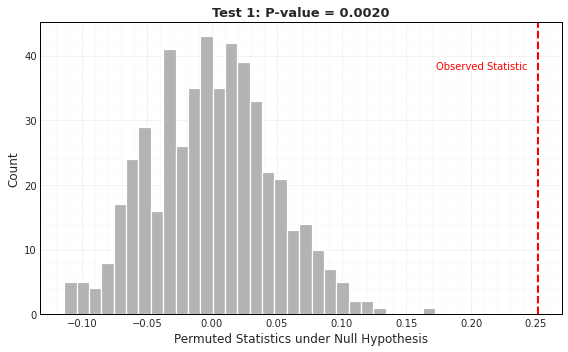

Figure saved to: results/task1_marginal_independence.png


In [4]:
# Match the style we used before
plt.style.use("seaborn-whitegrid")  # if this errors, try: "seaborn-whitegrid"

# Visualization: Task 1 (histogram only, styled)
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram: gray bars with white separators
ax.hist(
    codec_null_task1,
    bins=30,
    color="0.7",
    edgecolor="white",
    linewidth=1.2
)

# Observed statistic line + label text (no legend, no mean line)
ax.axvline(codec_observed_task1, color="red", linestyle="--", linewidth=2)

ymax = ax.get_ylim()[1]
ax.annotate(
    "Observed Statistic",
    xy=(codec_observed_task1, 0.85 * ymax),
    xytext=(-10, 0),              # move text left of the line (in points)
    textcoords="offset points",
    color="red",
    ha="right",
    va="center",
    fontsize=10,
)

# Labels / title (match prior conventions)
ax.set_xlabel("Permuted Statistics under Null Hypothesis", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Test 1: P-value = {p_value_task1:.4f}",
    fontsize=13,
    fontweight="bold",
)

# Grid + spines similar to the previous figures
ax.grid(True, which="major", alpha=0.30)
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.12)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/task1_marginal_independence.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to: results/task1_marginal_independence.png")

## Task 2: Residual Independence Test

Test if residuals of X2 are independent from the conditioning variables:
- res_X2 = X2 - E[X2|X1,X3]

Test: res_X2 ⊥ (X1, X3) using permutation test with CODEC score

In [5]:
# Load conditional expectation from Model 1
cond_exp = pd.read_csv('./results/discovery_model1/conditional_expectations.csv')
E_X2_given_X1_X3 = cond_exp['E_X2_given_X1_X3'].values.reshape(-1, 1)

# Compute residual
res_X2 = X2 - E_X2_given_X1_X3

# Prepare (X1, X3) for testing
X1_X3 = np.column_stack([X1, X3])

print("Residual computed:")
print(f"  res_X2: mean={res_X2.mean():.6f}, std={res_X2.std():.6f}")
print(f"\nConditioning variables (X1, X3):")
print(f"  Shape: {X1_X3.shape}")
print(f"  X1: mean={X1.mean():.6f}, std={X1.std():.6f}")
print(f"  X3: mean={X3.mean():.6f}, std={X3.std():.6f}")

Residual computed:
  res_X2: mean=0.583779, std=10.059857

Conditioning variables (X1, X3):
  Shape: (500, 2)
  X1: mean=0.006838, std=0.980272
  X3: mean=0.223372, std=3.212263


In [6]:
# Compute observed CODEC score: res_X2 vs (X1, X3)
print("\nComputing observed CODEC(res_X2, (X1, X3))...")
codec_observed_task2 = codec(res_X2, X1_X3)
print(f"Observed CODEC score: {codec_observed_task2:.6f}")

# Permutation test
print(f"\nPerforming {n_permutations} permutations...")

codec_null_task2 = []
np.random.seed(42)

for i in range(n_permutations):
    if (i + 1) % 100 == 0:
        print(f"  Permutation {i+1}/{n_permutations}...")
    
    # Permute res_X2
    res_X2_perm = res_X2[np.random.permutation(len(res_X2))]
    
    # Compute CODEC with permuted residuals
    codec_perm = codec(res_X2_perm, X1_X3)
    codec_null_task2.append(codec_perm)

codec_null_task2 = np.array(codec_null_task2)

# Compute p-value
num_larger = np.sum(codec_null_task2 >= codec_observed_task2)
p_value_task2 = (1 + num_larger) / (n_permutations + 1)

print(f"\nResults:")
print(f"  Observed CODEC:      {codec_observed_task2:.6f}")
print(f"  Null mean:           {codec_null_task2.mean():.6f}")
print(f"  Null std:            {codec_null_task2.std():.6f}")
print(f"  # larger or equal:   {num_larger}")
print(f"  P-value:             {p_value_task2:.6f}")
print(f"\nDecision (α=0.05): {'REJECT H0' if p_value_task2 <= 0.05 else 'FAIL TO REJECT H0'}")
print(f"  → res_X2 and (X1, X3) are {'NOT independent' if p_value_task2 <= 0.05 else 'independent'}")


Computing observed CODEC(res_X2, (X1, X3))...
Observed CODEC score: 0.106788

Performing 500 permutations...
  Permutation 100/500...
  Permutation 200/500...
  Permutation 300/500...
  Permutation 400/500...
  Permutation 500/500...

Results:
  Observed CODEC:      0.106788
  Null mean:           -0.004335
  Null std:            0.047454
  # larger or equal:   6
  P-value:             0.013972

Decision (α=0.05): REJECT H0
  → res_X2 and (X1, X3) are NOT independent


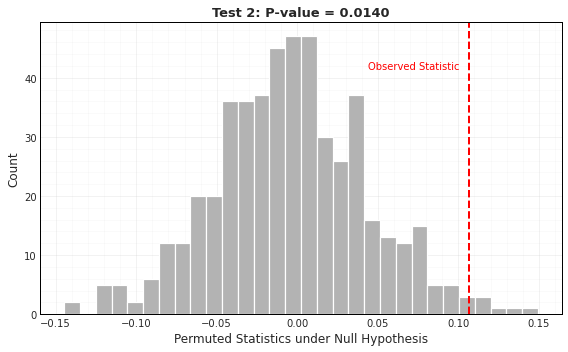

Figure saved to: results/task2_residual_independence.png


In [7]:
# Match the style we used before
plt.style.use("seaborn-whitegrid")  # if this errors, try: "seaborn-whitegrid"

# Visualization: Task 2 (histogram only, styled)
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram: gray bars with white separators
ax.hist(
    codec_null_task2,
    bins=30,
    color="0.7",
    edgecolor="white",
    linewidth=1.2
)

# Observed statistic line + label text (no legend, no mean line)
ax.axvline(codec_observed_task2, color="red", linestyle="--", linewidth=2)

ymax = ax.get_ylim()[1]
ax.annotate(
    "Observed Statistic",
    xy=(codec_observed_task2, 0.85 * ymax),
    xytext=(-10, 0),              # place text left of the red line
    textcoords="offset points",
    color="red",
    ha="right",
    va="center",
    fontsize=10,
)

# Labels / title (match prior conventions)
ax.set_xlabel("Permuted Statistics under Null Hypothesis", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Test 2: P-value = {p_value_task2:.4f}",
    fontsize=13,
    fontweight="bold",
)

# Grid + spines similar to the previous figures
ax.grid(True, which="major", alpha=0.30)
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.12)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/task2_residual_independence.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to: results/task2_residual_independence.png")

## Task 3: Conditional Independence Test (X1 ⊥ X3 | X2)

Visualize results from Model 2: X1 → X2 → X3

Test if X1 and X3 are conditionally independent given X2 using MCODEC + diffusion models.

In [8]:
# Load results from Model 2
tau_samples = pd.read_csv('./results/discovery_model2/tau_samples.csv')['tau_value'].values
tau_observed = pd.read_csv('./results/discovery_model2/tau_observed.csv')['tau_observed'].values[0]

# Compute p-value
num_larger = np.sum(tau_samples >= tau_observed)
p_value_task3 = (1 + num_larger) / (len(tau_samples) + 1)

print("Task 3: Conditional Independence Test Results")
print("="*70)
print(f"Test: X1 ⊥ X3 | X2")
print(f"\nObserved τ:          {tau_observed:.6f}")
print(f"Null mean:           {tau_samples.mean():.6f}")
print(f"Null std:            {tau_samples.std():.6f}")
print(f"Null range:          [{tau_samples.min():.6f}, {tau_samples.max():.6f}]")
print(f"# τ^(d) ≥ τ_obs:     {num_larger}")
print(f"MC samples:          {len(tau_samples)}")
print(f"P-value:             {p_value_task3:.6f}")
print(f"\nDecision (α=0.05): {'REJECT H0' if p_value_task3 <= 0.05 else 'FAIL TO REJECT H0'}")
print(f"  → X1 and X3 are {'NOT conditionally independent' if p_value_task3 <= 0.05 else 'conditionally independent'} given X2")

Task 3: Conditional Independence Test Results
Test: X1 ⊥ X3 | X2

Observed τ:          0.282061
Null mean:           -0.001307
Null std:            0.063713
Null range:          [-0.204573, 0.204795]
# τ^(d) ≥ τ_obs:     0
MC samples:          500
P-value:             0.001996

Decision (α=0.05): REJECT H0
  → X1 and X3 are NOT conditionally independent given X2


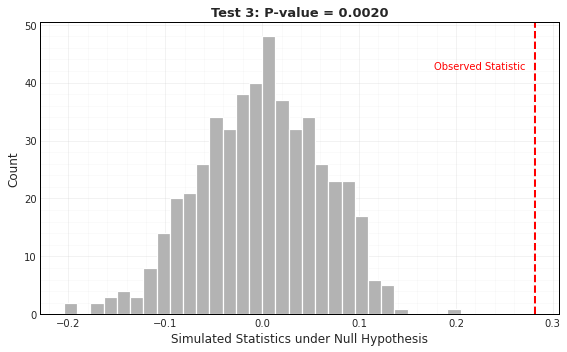

Figure saved to: results/task3_conditional_independence.png


In [9]:
# Match the style we used before
plt.style.use("seaborn-whitegrid")  # if this errors, try: "seaborn-whitegrid"

# Visualization: Task 3 (histogram only, styled)
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram: gray bars with white separators
ax.hist(
    tau_samples,
    bins=30,
    color="0.7",
    edgecolor="white",
    linewidth=1.2
)

# Observed statistic line + label text (no legend, no mean line)
ax.axvline(tau_observed, color="red", linestyle="--", linewidth=2)

ymax = ax.get_ylim()[1]
ax.annotate(
    "Observed Statistic",
    xy=(tau_observed, 0.85 * ymax),
    xytext=(-10, 0),              # place text left of the red line
    textcoords="offset points",
    color="red",
    ha="right",
    va="center",
    fontsize=10,
)

# Labels / title (match prior conventions)
ax.set_xlabel("Simulated Statistics under Null Hypothesis", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Test 3: P-value = {p_value_task3:.4f}",
    fontsize=13,
    fontweight="bold",
)

# Grid + spines similar to the previous figures
ax.grid(True, which="major", alpha=0.30)
ax.minorticks_on()
ax.grid(True, which="minor", alpha=0.12)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/task3_conditional_independence.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to: results/task3_conditional_independence.png")

## Summary of All Tests

In [10]:
# Create summary table
summary_data = [
    {
        'Test': 'Task 1: X1 ⊥ X3',
        'Type': 'Marginal',
        'Method': 'Permutation (CODEC)',
        'Observed': f'{codec_observed_task1:.6f}',
        'P-value': f'{p_value_task1:.6f}',
        'Decision': 'Reject H0' if p_value_task1 <= 0.05 else 'Fail to Reject H0'
    },
    {
        'Test': 'Task 2: res_X2 ⊥ (X1, X3)',
        'Type': 'Marginal',
        'Method': 'Permutation (CODEC)',
        'Observed': f'{codec_observed_task2:.6f}',
        'P-value': f'{p_value_task2:.6f}',
        'Decision': 'Reject H0' if p_value_task2 <= 0.05 else 'Fail to Reject H0'
    },
    {
        'Test': 'Task 3: X1 ⊥ X3 | X2',
        'Type': 'Conditional',
        'Method': 'Diffusion + MCODEC',
        'Observed': f'{tau_observed:.6f}',
        'P-value': f'{p_value_task3:.6f}',
        'Decision': 'Reject H0' if p_value_task3 <= 0.05 else 'Fail to Reject H0'
    }
]

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY OF ALL INDEPENDENCE TESTS (α = 0.05)")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Save summary
summary_df.to_csv('results/discovery_tests_summary.csv', index=False)
print("\nSummary saved to: results/discovery_tests_summary.csv")


SUMMARY OF ALL INDEPENDENCE TESTS (α = 0.05)
                      Test         Type               Method  Observed   P-value   Decision
           Task 1: X1 ⊥ X3     Marginal  Permutation (CODEC)  0.251461  0.001996  Reject H0
 Task 2: res_X2 ⊥ (X1, X3)     Marginal  Permutation (CODEC)  0.106788  0.013972  Reject H0
      Task 3: X1 ⊥ X3 | X2  Conditional   Diffusion + MCODEC  0.282061  0.001996  Reject H0

Summary saved to: results/discovery_tests_summary.csv
